In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data = pd.read_csv("house_price.csv")
data.columns = data.columns.str.strip()
print(data)

X = data[['Area']]
y = data['Price']

   Area  Price
0   800     25
1  1000     30
2  1200     36
3  1400     42
4  1500     45
5  1600     48
6  1800     54
7  2000     60
8  2200     66
9  2400     72


In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])
y_pred = model.predict(X_val)

print("Actual values:")
print(y_val.values)

print("Predicted values:")
print(y_pred)

Intercept: 0.8652849740932638
Coefficient: 0.029533678756476684
Actual values:
[66 30]
Predicted values:
[65.83937824 30.39896373]


In [5]:
# Predict price for a 1700 sq.ft house
new_house = pd.DataFrame({'Area': [1700]})
prediction = model.predict(new_house)
print("Predicted price:", prediction[0], "lakhs")

# Evaluation
mae = mean_absolute_error(y_val, y_pred)
print("MAE:", mae)

mse = mean_squared_error(y_val, y_pred)
print("MSE:", mse)

Predicted price: 51.07253886010363 lakhs
MAE: 0.2797927461139924
MSE: 0.092485704314211


In [4]:
rmse = mean_squared_error(y_val, y_pred) ** 0.5

print("RMSE:", rmse)

r2 = r2_score(y_val, y_pred)

print("R2 Score:", r2)

result = pd.DataFrame({
    'Actual Price': y_val.values,
    'Predicted Price': y_pred
})
print(result)

RMSE: 0.3041146236441303
R2 Score: 0.9997145502953265
   Actual Price  Predicted Price
0            66        65.839378
1            30        30.398964


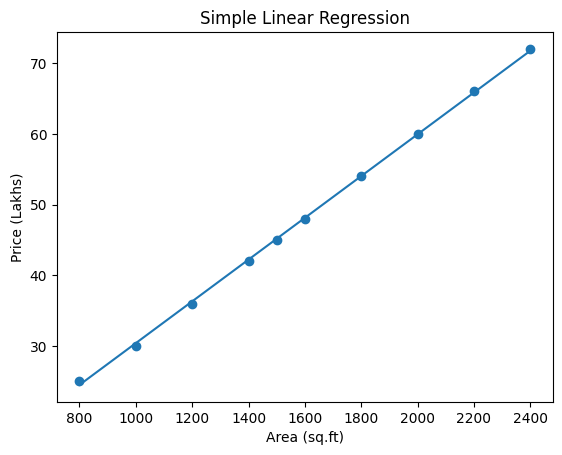

In [5]:
plt.scatter(X, y)

plt.plot(X, model.predict(X))

plt.xlabel("Area (sq.ft)")
plt.ylabel("Price (Lakhs)")
plt.title("Simple Linear Regression")

plt.show()